In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Check column names, data types, and missing values
print("=== Column Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobL

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Drop columns that have no analytical value (constant values)
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

# Convert Attrition to binary numeric (Yes=1, No=0)
# This will be very useful for calculations later
df['AttritionBinary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Verify the changes
print("New shape:", df.shape)
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())
print("\nAttrition rate: {:.1f}%".format(df['AttritionBinary'].mean() * 100))

New shape: (1470, 33)

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [7]:
# Map numeric codes to meaningful labels
df['EducationLabel'] = df['Education'].map({
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
})

df['JobSatisfactionLabel'] = df['JobSatisfaction'].map({
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
})

df['WorkLifeBalanceLabel'] = df['WorkLifeBalance'].map({
    1: 'Bad',
    2: 'Good',
    3: 'Better',
    4: 'Best'
})

df['EnvironmentSatisfactionLabel'] = df['EnvironmentSatisfaction'].map({
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
})

# Confirm new columns added
print("New shape:", df.shape)
print("\nSample of new label columns:")
df[['Education', 'EducationLabel', 'JobSatisfaction', 'JobSatisfactionLabel']].head()

New shape: (1470, 37)

Sample of new label columns:


,Education,EducationLabel,JobSatisfaction,JobSatisfactionLabel
0,2,College,4,Very High
1,1,Below College,2,Medium
2,2,College,3,High
3,4,Master,3,High
4,1,Below College,2,Medium


In [8]:
# Save the cleaned dataset to the data folder
df.to_csv('../data/hr_attrition_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)
print("\nFinal columns:")
for col in df.columns:
    print(" -", col)

Cleaned dataset saved successfully!
Shape: (1470, 37)

Final columns:
 - Age
 - Attrition
 - BusinessTravel
 - DailyRate
 - Department
 - DistanceFromHome
 - Education
 - EducationField
 - EmployeeNumber
 - EnvironmentSatisfaction
 - Gender
 - HourlyRate
 - JobInvolvement
 - JobLevel
 - JobRole
 - JobSatisfaction
 - MaritalStatus
 - MonthlyIncome
 - MonthlyRate
 - NumCompaniesWorked
 - OverTime
 - PercentSalaryHike
 - PerformanceRating
 - RelationshipSatisfaction
 - StockOptionLevel
 - TotalWorkingYears
 - TrainingTimesLastYear
 - WorkLifeBalance
 - YearsAtCompany
 - YearsInCurrentRole
 - YearsSinceLastPromotion
 - YearsWithCurrManager
 - AttritionBinary
 - EducationLabel
 - JobSatisfactionLabel
 - WorkLifeBalanceLabel
 - EnvironmentSatisfactionLabel


In [9]:
# Chart styling setup
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("Chart styling ready!")

Chart styling ready!


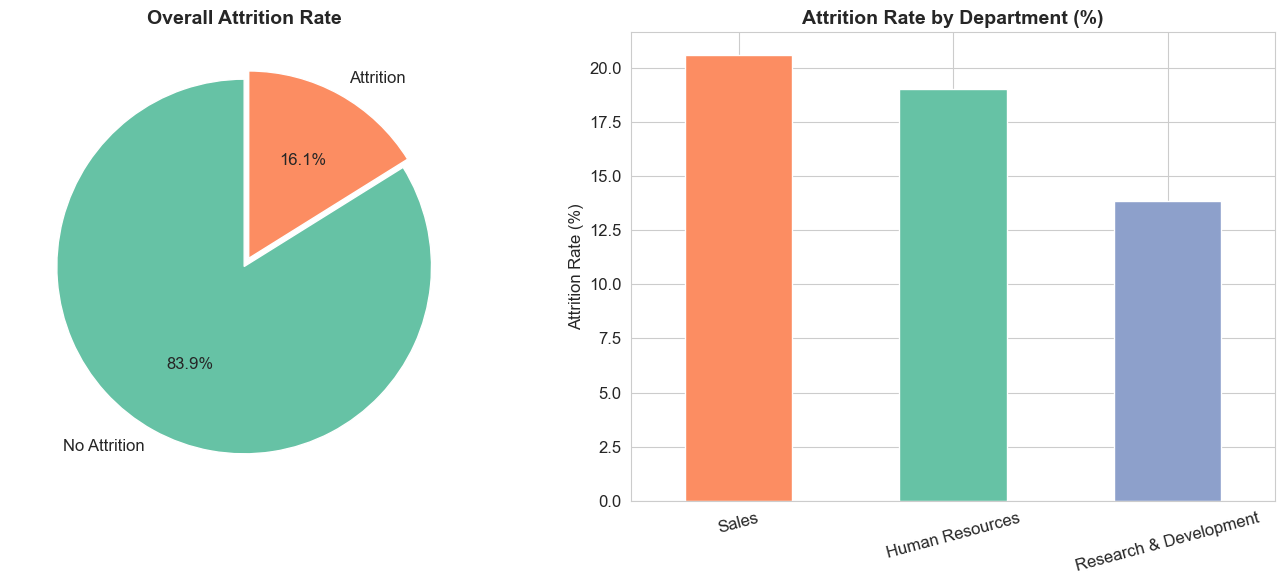

Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Pie chart - Overall attrition rate
attrition_counts = df['Attrition'].value_counts()
axes[0].pie(attrition_counts, labels=['No Attrition', 'Attrition'], 
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Overall Attrition Rate', fontweight='bold', fontsize=14)

# Chart 2: Attrition by Department
dept_attrition = df.groupby('Department')['AttritionBinary'].mean() * 100
dept_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[1], 
                                                   color=['#fc8d62','#66c2a5','#8da0cb'],
                                                   edgecolor='white')
axes[1].set_title('Attrition Rate by Department (%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/chart1_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

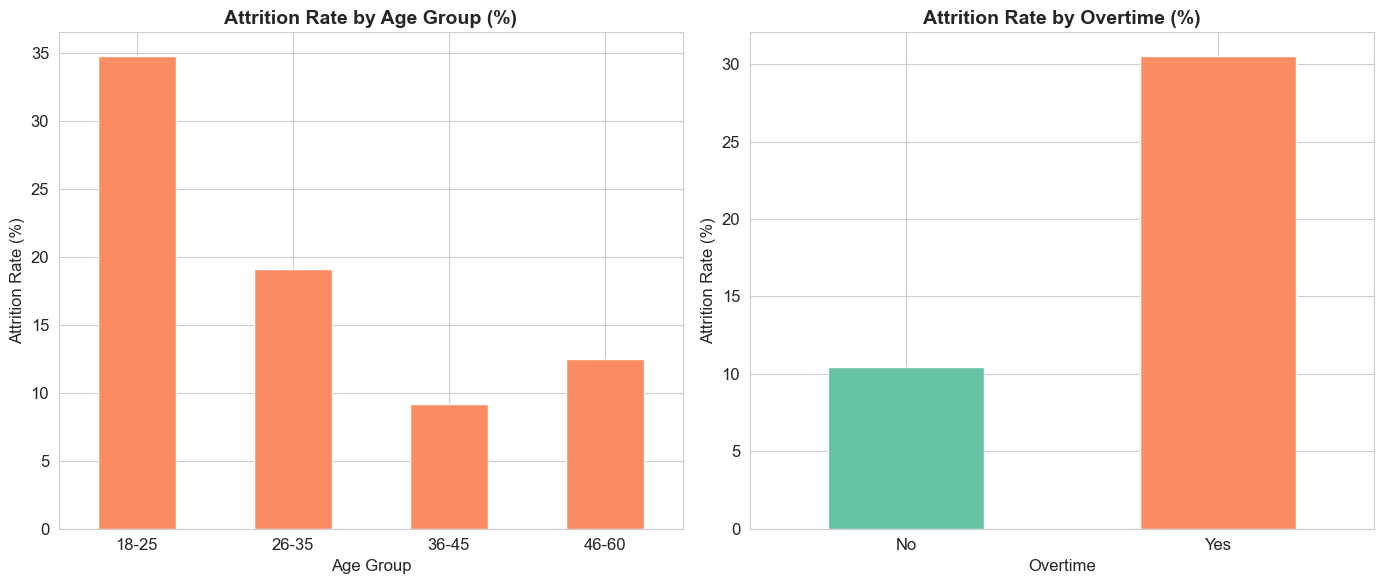

Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 3: Attrition by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60], 
                         labels=['18-25', '26-35', '36-45', '46-60'])
age_attrition = df.groupby('AgeGroup', observed=True)['AttritionBinary'].mean() * 100
age_attrition.plot(kind='bar', ax=axes[0], color='#fc8d62', edgecolor='white')
axes[0].set_title('Attrition Rate by Age Group (%)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Chart 4: Attrition by Overtime
overtime_attrition = df.groupby('OverTime')['AttritionBinary'].mean() * 100
overtime_attrition.plot(kind='bar', ax=axes[1], 
                        color=['#66c2a5', '#fc8d62'], edgecolor='white')
axes[1].set_title('Attrition Rate by Overtime (%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Overtime')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/chart2_age_overtime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

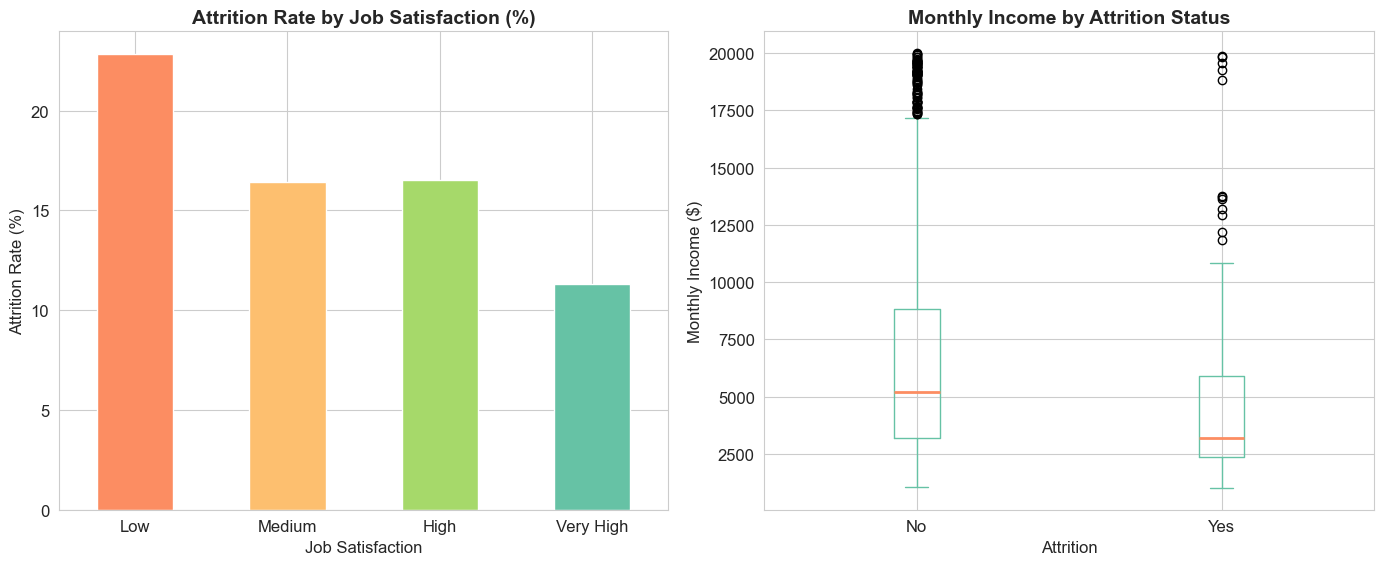

Chart saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 5: Attrition by Job Satisfaction
sat_order = ['Low', 'Medium', 'High', 'Very High']
sat_attrition = df.groupby('JobSatisfactionLabel')['AttritionBinary'].mean() * 100
sat_attrition = sat_attrition.reindex(sat_order)
sat_attrition.plot(kind='bar', ax=axes[0], 
                   color=['#fc8d62','#fdbf6f','#a6d96a','#66c2a5'], edgecolor='white')
axes[0].set_title('Attrition Rate by Job Satisfaction (%)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Job Satisfaction')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Chart 6: Monthly Income Distribution by Attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1],
           boxprops=dict(color='#66c2a5'),
           medianprops=dict(color='#fc8d62', linewidth=2),
           whiskerprops=dict(color='#66c2a5'),
           capprops=dict(color='#66c2a5'))
axes[1].set_title('Monthly Income by Attrition Status', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputs/chart3_satisfaction_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

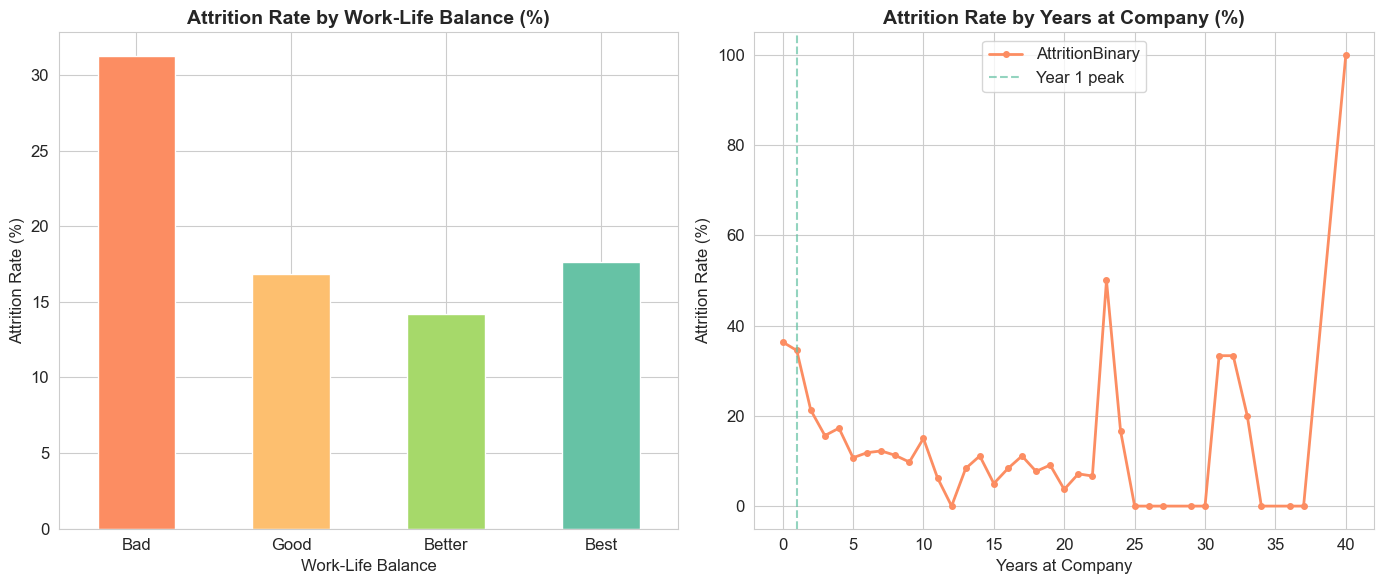

Chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 7: Attrition by Work-Life Balance
wlb_order = ['Bad', 'Good', 'Better', 'Best']
wlb_attrition = df.groupby('WorkLifeBalanceLabel')['AttritionBinary'].mean() * 100
wlb_attrition = wlb_attrition.reindex(wlb_order)
wlb_attrition.plot(kind='bar', ax=axes[0],
                   color=['#fc8d62','#fdbf6f','#a6d96a','#66c2a5'], edgecolor='white')
axes[0].set_title('Attrition Rate by Work-Life Balance (%)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Work-Life Balance')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Chart 8: Attrition by Years at Company
years_attrition = df.groupby('YearsAtCompany')['AttritionBinary'].mean() * 100
years_attrition.plot(kind='line', ax=axes[1], color='#fc8d62', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Attrition Rate by Years at Company (%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Years at Company')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].axvline(x=1, color='#66c2a5', linestyle='--', alpha=0.7, label='Year 1 peak')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/chart4_worklife_years.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

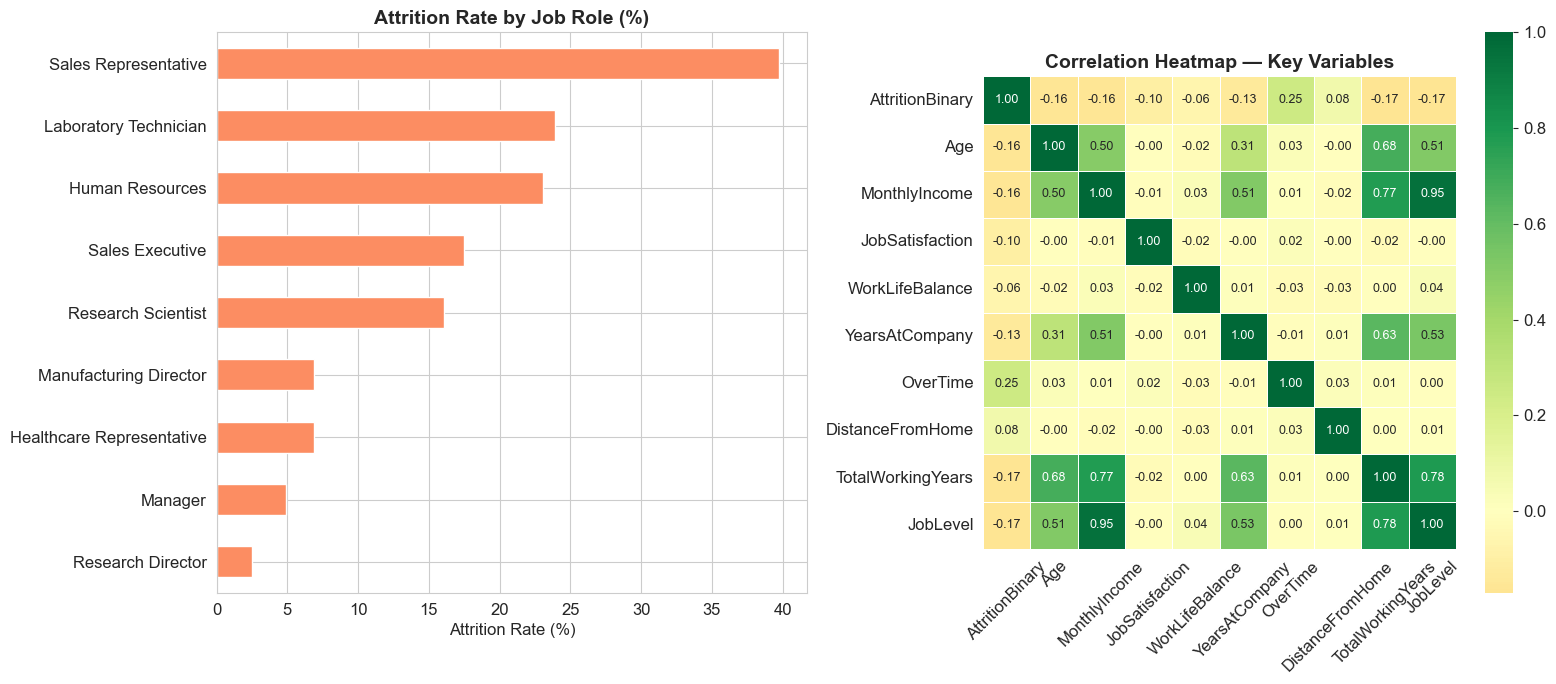

Chart saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 9: Attrition by Job Role (horizontal bar)
role_attrition = df.groupby('JobRole')['AttritionBinary'].mean() * 100
role_attrition.sort_values().plot(kind='barh', ax=axes[0], 
                                   color='#fc8d62', edgecolor='white')
axes[0].set_title('Attrition Rate by Job Role (%)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_ylabel('')

# Chart 10: Correlation heatmap of key numeric variables
cols = ['AttritionBinary', 'Age', 'MonthlyIncome', 'JobSatisfaction',
        'WorkLifeBalance', 'YearsAtCompany', 'OverTime',
        'DistanceFromHome', 'TotalWorkingYears', 'JobLevel']

df_corr = df[cols].copy()
df_corr['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 9})
axes[1].set_title('Correlation Heatmap — Key Variables', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/chart5_jobrole_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [15]:
print("=" * 50)
print("   EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"  Overall attrition rate      : 16.1%")
print(f"  Highest risk department     : Sales (21%)")
print(f"  Highest risk age group      : 18-25 (35%)")
print(f"  Highest risk job role       : Sales Rep (40%)")
print(f"  Overtime attrition rate     : 30.5%")
print(f"  Non-overtime attrition rate : 10.4%")
print(f"  Median income (left)        : ~$3,000/mo")
print(f"  Median income (stayed)      : ~$5,200/mo")
print(f"  Strongest attrition driver  : OverTime (r=0.25)")
print("=" * 50)
print("  Charts saved to /outputs folder")
print("=" * 50)

   EDA COMPLETE — KEY FINDINGS SUMMARY
  Overall attrition rate      : 16.1%
  Highest risk department     : Sales (21%)
  Highest risk age group      : 18-25 (35%)
  Highest risk job role       : Sales Rep (40%)
  Overtime attrition rate     : 30.5%
  Non-overtime attrition rate : 10.4%
  Median income (left)        : ~$3,000/mo
  Median income (stayed)      : ~$5,200/mo
  Strongest attrition driver  : OverTime (r=0.25)
  Charts saved to /outputs folder


In [16]:
import sqlite3

# Create SQLite database and load the cleaned data
conn = sqlite3.connect('../sql/hr_attrition.db')

# Write the cleaned dataframe into the database as a table
df.to_sql('employees', conn, if_exists='replace', index=False)

# Verify it loaded correctly
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM employees")
print("Total rows in database:", cursor.fetchone()[0])

cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print("Tables in database:", cursor.fetchall())

print("\nDatabase created successfully at /sql/hr_attrition.db!")

Total rows in database: 1470
Tables in database: [('employees',)]

Database created successfully at /sql/hr_attrition.db!


In [17]:
# Helper function to run SQL and display results neatly
def run_query(title, query):
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))
    return result

# Query 1: Overall attrition summary
run_query("Q1: Overall Attrition Summary", """
    SELECT 
        Attrition,
        COUNT(*) AS EmployeeCount,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 1) AS Percentage
    FROM employees
    GROUP BY Attrition
    ORDER BY EmployeeCount DESC
""")

# Query 2: Attrition rate by department
run_query("Q2: Attrition Rate by Department", """
    SELECT 
        Department,
        COUNT(*) AS TotalEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
    FROM employees
    GROUP BY Department
    ORDER BY AttritionRate_Pct DESC
""")


  Q1: Overall Attrition Summary
Attrition  EmployeeCount  Percentage
       No           1233        83.9
      Yes            237        16.1

  Q2: Attrition Rate by Department
            Department  TotalEmployees  Attrited  AttritionRate_Pct
                 Sales             446        92               20.6
       Human Resources              63        12               19.0
Research & Development             961       133               13.8


,Department,TotalEmployees,Attrited,AttritionRate_Pct
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research & Development,961,133,13.8


In [18]:
# Query 3: Attrition by Job Role (ranked)
run_query("Q3: Attrition Rate by Job Role", """
    SELECT 
        JobRole,
        COUNT(*) AS TotalEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
    FROM employees
    GROUP BY JobRole
    ORDER BY AttritionRate_Pct DESC
""")

# Query 4: Overtime impact on attrition
run_query("Q4: Overtime Impact on Attrition", """
    SELECT 
        OverTime,
        COUNT(*) AS TotalEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
        ROUND(AVG(MonthlyIncome), 0) AS AvgMonthlyIncome
    FROM employees
    GROUP BY OverTime
    ORDER BY AttritionRate_Pct DESC
""")

# Query 5: Average income comparison — stayed vs left
run_query("Q5: Income Comparison — Stayed vs Left", """
    SELECT 
        Attrition,
        ROUND(AVG(MonthlyIncome), 0) AS AvgMonthlyIncome,
        ROUND(MIN(MonthlyIncome), 0) AS MinIncome,
        ROUND(MAX(MonthlyIncome), 0) AS MaxIncome,
        ROUND(AVG(Age), 1) AS AvgAge,
        ROUND(AVG(TotalWorkingYears), 1) AS AvgWorkingYears
    FROM employees
    GROUP BY Attrition
""")

# Query 6: High risk employee profile
run_query("Q6: High Risk Segment — Young + Overtime + Low Income", """
    SELECT 
        COUNT(*) AS HighRiskEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
        ROUND(AVG(MonthlyIncome), 0) AS AvgIncome
    FROM employees
    WHERE Age <= 25 
      AND OverTime = 'Yes' 
      AND JobSatisfaction <= 2
""")


  Q3: Attrition Rate by Job Role
                  JobRole  TotalEmployees  Attrited  AttritionRate_Pct
     Sales Representative              83        33               39.8
    Laboratory Technician             259        62               23.9
          Human Resources              52        12               23.1
          Sales Executive             326        57               17.5
       Research Scientist             292        47               16.1
   Manufacturing Director             145        10                6.9
Healthcare Representative             131         9                6.9
                  Manager             102         5                4.9
        Research Director              80         2                2.5

  Q4: Overtime Impact on Attrition
OverTime  TotalEmployees  Attrited  AttritionRate_Pct  AvgMonthlyIncome
     Yes             416       127               30.5            6549.0
      No            1054       110               10.4            6485.0

  Q

,HighRiskEmployees,Attrited,AttritionRate_Pct,AvgIncome
0,15,11,73.3,2457.0


In [19]:
# Query 7: Attrition by years at company (early tenure focus)
run_query("Q7: Attrition by Tenure Band", """
    SELECT 
        CASE 
            WHEN YearsAtCompany <= 1 THEN '0-1 Years'
            WHEN YearsAtCompany <= 3 THEN '2-3 Years'
            WHEN YearsAtCompany <= 5 THEN '4-5 Years'
            WHEN YearsAtCompany <= 10 THEN '6-10 Years'
            ELSE '10+ Years'
        END AS TenureBand,
        COUNT(*) AS TotalEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
    FROM employees
    GROUP BY TenureBand
    ORDER BY AttritionRate_Pct DESC
""")

# Query 8: Department + Overtime combination risk
run_query("Q8: Department vs Overtime Attrition Risk", """
    SELECT 
        Department,
        OverTime,
        COUNT(*) AS TotalEmployees,
        SUM(AttritionBinary) AS Attrited,
        ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
        ROUND(AVG(MonthlyIncome), 0) AS AvgIncome
    FROM employees
    GROUP BY Department, OverTime
    ORDER BY AttritionRate_Pct DESC
""")


  Q7: Attrition by Tenure Band
TenureBand  TotalEmployees  Attrited  AttritionRate_Pct
 0-1 Years             215        75               34.9
 2-3 Years             255        47               18.4
 4-5 Years             306        40               13.1
6-10 Years             448        55               12.3
 10+ Years             246        20                8.1

  Q8: Department vs Overtime Attrition Risk
            Department OverTime  TotalEmployees  Attrited  AttritionRate_Pct  AvgIncome
                 Sales      Yes             128        48               37.5     6993.0
       Human Resources      Yes              17         5               29.4     7281.0
Research & Development      Yes             271        74               27.3     6293.0
       Human Resources       No              46         7               15.2     6423.0
                 Sales       No             318        44               13.8     6946.0
Research & Development       No             690        59  

,Department,OverTime,TotalEmployees,Attrited,AttritionRate_Pct,AvgIncome
0,Sales,Yes,128,48,37.5,6993.0
1,Human Resources,Yes,17,5,29.4,7281.0
2,Research & Development,Yes,271,74,27.3,6293.0
3,Human Resources,No,46,7,15.2,6423.0
4,Sales,No,318,44,13.8,6946.0
5,Research & Development,No,690,59,8.6,6277.0


In [20]:
sql_script = """-- ============================================
-- HR Attrition Analysis — SQL Queries
-- Database: hr_attrition.db
-- Author: Sanju Thomas Sabu
-- ============================================

-- Q1: Overall Attrition Summary
SELECT 
    Attrition,
    COUNT(*) AS EmployeeCount,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 1) AS Percentage
FROM employees
GROUP BY Attrition
ORDER BY EmployeeCount DESC;

-- Q2: Attrition Rate by Department
SELECT 
    Department,
    COUNT(*) AS TotalEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
FROM employees
GROUP BY Department
ORDER BY AttritionRate_Pct DESC;

-- Q3: Attrition Rate by Job Role
SELECT 
    JobRole,
    COUNT(*) AS TotalEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
FROM employees
GROUP BY JobRole
ORDER BY AttritionRate_Pct DESC;

-- Q4: Overtime Impact on Attrition
SELECT 
    OverTime,
    COUNT(*) AS TotalEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
    ROUND(AVG(MonthlyIncome), 0) AS AvgMonthlyIncome
FROM employees
GROUP BY OverTime
ORDER BY AttritionRate_Pct DESC;

-- Q5: Income Comparison — Stayed vs Left
SELECT 
    Attrition,
    ROUND(AVG(MonthlyIncome), 0) AS AvgMonthlyIncome,
    ROUND(MIN(MonthlyIncome), 0) AS MinIncome,
    ROUND(MAX(MonthlyIncome), 0) AS MaxIncome,
    ROUND(AVG(Age), 1) AS AvgAge,
    ROUND(AVG(TotalWorkingYears), 1) AS AvgWorkingYears
FROM employees
GROUP BY Attrition;

-- Q6: High Risk Segment — Young + Overtime + Low Satisfaction
SELECT 
    COUNT(*) AS HighRiskEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
    ROUND(AVG(MonthlyIncome), 0) AS AvgIncome
FROM employees
WHERE Age <= 25 
  AND OverTime = 'Yes' 
  AND JobSatisfaction <= 2;

-- Q7: Attrition by Tenure Band
SELECT 
    CASE 
        WHEN YearsAtCompany <= 1 THEN '0-1 Years'
        WHEN YearsAtCompany <= 3 THEN '2-3 Years'
        WHEN YearsAtCompany <= 5 THEN '4-5 Years'
        WHEN YearsAtCompany <= 10 THEN '6-10 Years'
        ELSE '10+ Years'
    END AS TenureBand,
    COUNT(*) AS TotalEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct
FROM employees
GROUP BY TenureBand
ORDER BY AttritionRate_Pct DESC;

-- Q8: Department vs Overtime Attrition Risk
SELECT 
    Department,
    OverTime,
    COUNT(*) AS TotalEmployees,
    SUM(AttritionBinary) AS Attrited,
    ROUND(SUM(AttritionBinary) * 100.0 / COUNT(*), 1) AS AttritionRate_Pct,
    ROUND(AVG(MonthlyIncome), 0) AS AvgIncome
FROM employees
GROUP BY Department, OverTime
ORDER BY AttritionRate_Pct DESC;
"""

with open('../sql/hr_queries.sql', 'w') as f:
    f.write(sql_script)

conn.close()
print("SQL script saved to /sql/hr_queries.sql!")
print("Database connection closed.")

SQL script saved to /sql/hr_queries.sql!
Database connection closed.
